# YOLOv8 + EasyOCR для распознавания ценников

Этот ноутбук обучает модель YOLOv8 на размеченных данных ценников и использует EasyOCR для распознавания текста.

## 2. Импорты

In [1]:
import pathlib
import shutil
import csv
import cv2
import math
import random
import numpy as np
import pandas as pd
import easyocr
from pyzbar.pyzbar import decode as pyzbar_decode
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml
import logging
from typing import Dict, List, Tuple, Optional
import tempfile
import os

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# Загружаем модель для super-resolution
sr = cv2.dnn_superres.DnnSuperResImpl_create()
# Определяем путь к ESPCN модели (может быть ../weight/ или weight/ в зависимости от того, где запускается ноутбук)
ESPCN_MODEL_CANDIDATES = [
    "weight/ESPCN_x4.pb",
    "../weight/ESPCN_x4.pb",
    "weights/ESPCN_x4.pb",
    "../weights/ESPCN_x4.pb",
]
ESPCN_SCALE = 4

ESPCN_MODEL_PATH = None
for candidate in ESPCN_MODEL_CANDIDATES:
    if pathlib.Path(candidate).exists():
        ESPCN_MODEL_PATH = candidate
        break

ESPCN_AVAILABLE = False
if ESPCN_MODEL_PATH is not None:
    try:
        sr.readModel(ESPCN_MODEL_PATH)
        sr.setModel("espcn", ESPCN_SCALE)
        logger.info(f"✓ ESPCN модель загружена: {ESPCN_MODEL_PATH}")
        ESPCN_AVAILABLE = True
    except Exception as e:
        logger.warning(f"✗ Не удалось загрузить ESPCN модель: {e}")
else:
    logger.warning(f"✗ Файл ESPCN модели не найден. Проверены пути: {ESPCN_MODEL_CANDIDATES}")

[INFO] ✓ ESPCN модель загружена: ../weight/ESPCN_x4.pb


## 5. Инициализация YOLOv8 модели

In [4]:
model = YOLO('yolov8n.pt')  # Автоматически скачается при первом запуске
logger.info(f"Модель YOLOv8 загружена")

[INFO] Модель YOLOv8 загружена


## 6. Функция для вырезания ценников из видео

In [5]:
class PriceTagExtractor:
    """Вырезает ценники из видео по таймкодам и координатам"""
    
    def __init__(self, video_path: str, csv_path: str):
        self.video_path = pathlib.Path(video_path)
        self.csv_path = pathlib.Path(csv_path)
        self.video_data = self._load_csv()
        
    def _load_csv(self) -> pd.DataFrame:
        """Загружает CSV с координатами ценников"""
        try:
            df = pd.read_csv(self.csv_path, encoding='utf-8-sig')
            logger.info(f"[OK] Загружено {len(df)} записей из CSV")
            return df
        except Exception as e:
            logger.error(f"Ошибка при загрузке CSV: {e}")
            return pd.DataFrame()
    
    def extract_tags(self, output_dir: str = None) -> pathlib.Path:
        """Вырезает ценники по координатам из видео"""
        if len(self.video_data) == 0:
            logger.error("CSV данные не загружены")
            return None
        
        with tempfile.TemporaryDirectory() as td:
            temp_video = pathlib.Path(td) / 'video.mp4'
            shutil.copyfile(self.video_path, temp_video)
            cap = cv2.VideoCapture(str(temp_video))
            if not cap.isOpened():
                logger.error(f"Не удалось открыть видео: {temp_video}")
                return None
            
            fps = cap.get(cv2.CAP_PROP_FPS)
            logger.info(f"[INFO] Загружено видео: {self.video_path.name}  (FPS: {fps})")
            
            if output_dir is None:
                output_dir = self.video_path.parent / "extracted_price_tags"
            else:
                output_dir = pathlib.Path(output_dir)
            
            output_dir.mkdir(parents=True, exist_ok=True)
            
            grouped = self.video_data.groupby('frame_timestamp')
            extracted_count = 0
            metadata = []
            
            for frame_num, group in grouped:
                frame_num = int(frame_num)
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
                ret, frame = cap.read()
                
                if not ret:
                    logger.warning(f"[WARN] Не удалось прочитать кадр {frame_num} из {self.video_path.name}")
                    continue
                
                for idx, row in group.iterrows():
                    try:
                        x_min = int(float(str(row['x_min']).replace(',', '.')))
                        y_min = int(float(str(row['y_min']).replace(',', '.')))
                        x_max = int(float(str(row['x_max']).replace(',', '.')))
                        y_max = int(float(str(row['y_max']).replace(',', '.')))
                        
                        x_min, x_max = min(x_min, x_max), max(x_min, x_max)
                        y_min, y_max = min(y_min, y_max), max(y_min, y_max)
                        
                        crop = frame[y_min:y_max, x_min:x_max]
                        
                        if crop.size > 0:
                            sku = str(row.get('id_sku', 'unknown')).replace('/', '_')
                            filename = f"{frame_num:06d}_sku_{sku}.jpg"
                            filepath = output_dir / filename
                            cv2.imwrite(str(filepath), crop)
                            extracted_count += 1
                            
                            metadata.append({
                                'filename': filename,
                                'frame': frame_num,
                                'sku': sku,
                                'product': row.get('product_name', ''),
                                'price': row.get('price_card', ''),
                                'x_min': x_min, 'y_min': y_min, 'x_max': x_max, 'y_max': y_max
                            })
                    except Exception as e:
                        logger.debug(f"Пропуск записи: {e}")
                        continue
            
            cap.release()
            logger.info(f"[DONE] Все ценники сохранены в папку: {output_dir}")
            
            if metadata:
                metadata_df = pd.DataFrame(metadata)
                metadata_path = output_dir / "extracted_tags_metadata.csv"
                metadata_df.to_csv(metadata_path, index=False, encoding='utf-8-sig')
                logger.info(f"[INFO] Создан файл с метаданными: {metadata_path}")
            
            return output_dir

logger.info("PriceTagExtractor инициализирован")

[INFO] PriceTagExtractor инициализирован


## 7. Инициализация EasyOCR

In [6]:
ocr_reader = easyocr.Reader(['ru', 'en'], gpu=False)
logger.info("EasyOCR инициализирован для [ru, en]")

[WARNING] Using CPU. Note: This module is much faster with a GPU.
[INFO] EasyOCR инициализирован для [ru, en]


## 8. Функции для распознавания текста в ценниках и декодирования QR/штрихкодов

## 10. Загрузка обученных весов

In [22]:
import pathlib
from typing import Optional
from ultralytics import YOLO

# Явно указываем путь к проекту
PROJECT_ROOT = pathlib.Path(r"D:\Lenta-Tech-Life-Hack-2026")
WEIGHTS_PATH = PROJECT_ROOT / "weight" / "best.pt"

# Проверяем существование
if WEIGHTS_PATH.exists():
    logger.info(f"Найдены веса: {WEIGHTS_PATH}")
    trained_model = YOLO(str(WEIGHTS_PATH))
else:
    logger.error(f"Веса не найдены по пути: {WEIGHTS_PATH}")
    trained_model = None

trained_model = YOLO(str(WEIGHTS_PATH)) if WEIGHTS_PATH is not None else None
if trained_model is not None:
    logger.info(f"Загружены веса модели: {WEIGHTS_PATH}")

[INFO] Найдены веса: D:\Lenta-Tech-Life-Hack-2026\weight\best.pt
[INFO] Загружены веса модели: D:\Lenta-Tech-Life-Hack-2026\weight\best.pt


## 13. Визуализация на `outputs/extracted_price_tags_25_12_20`

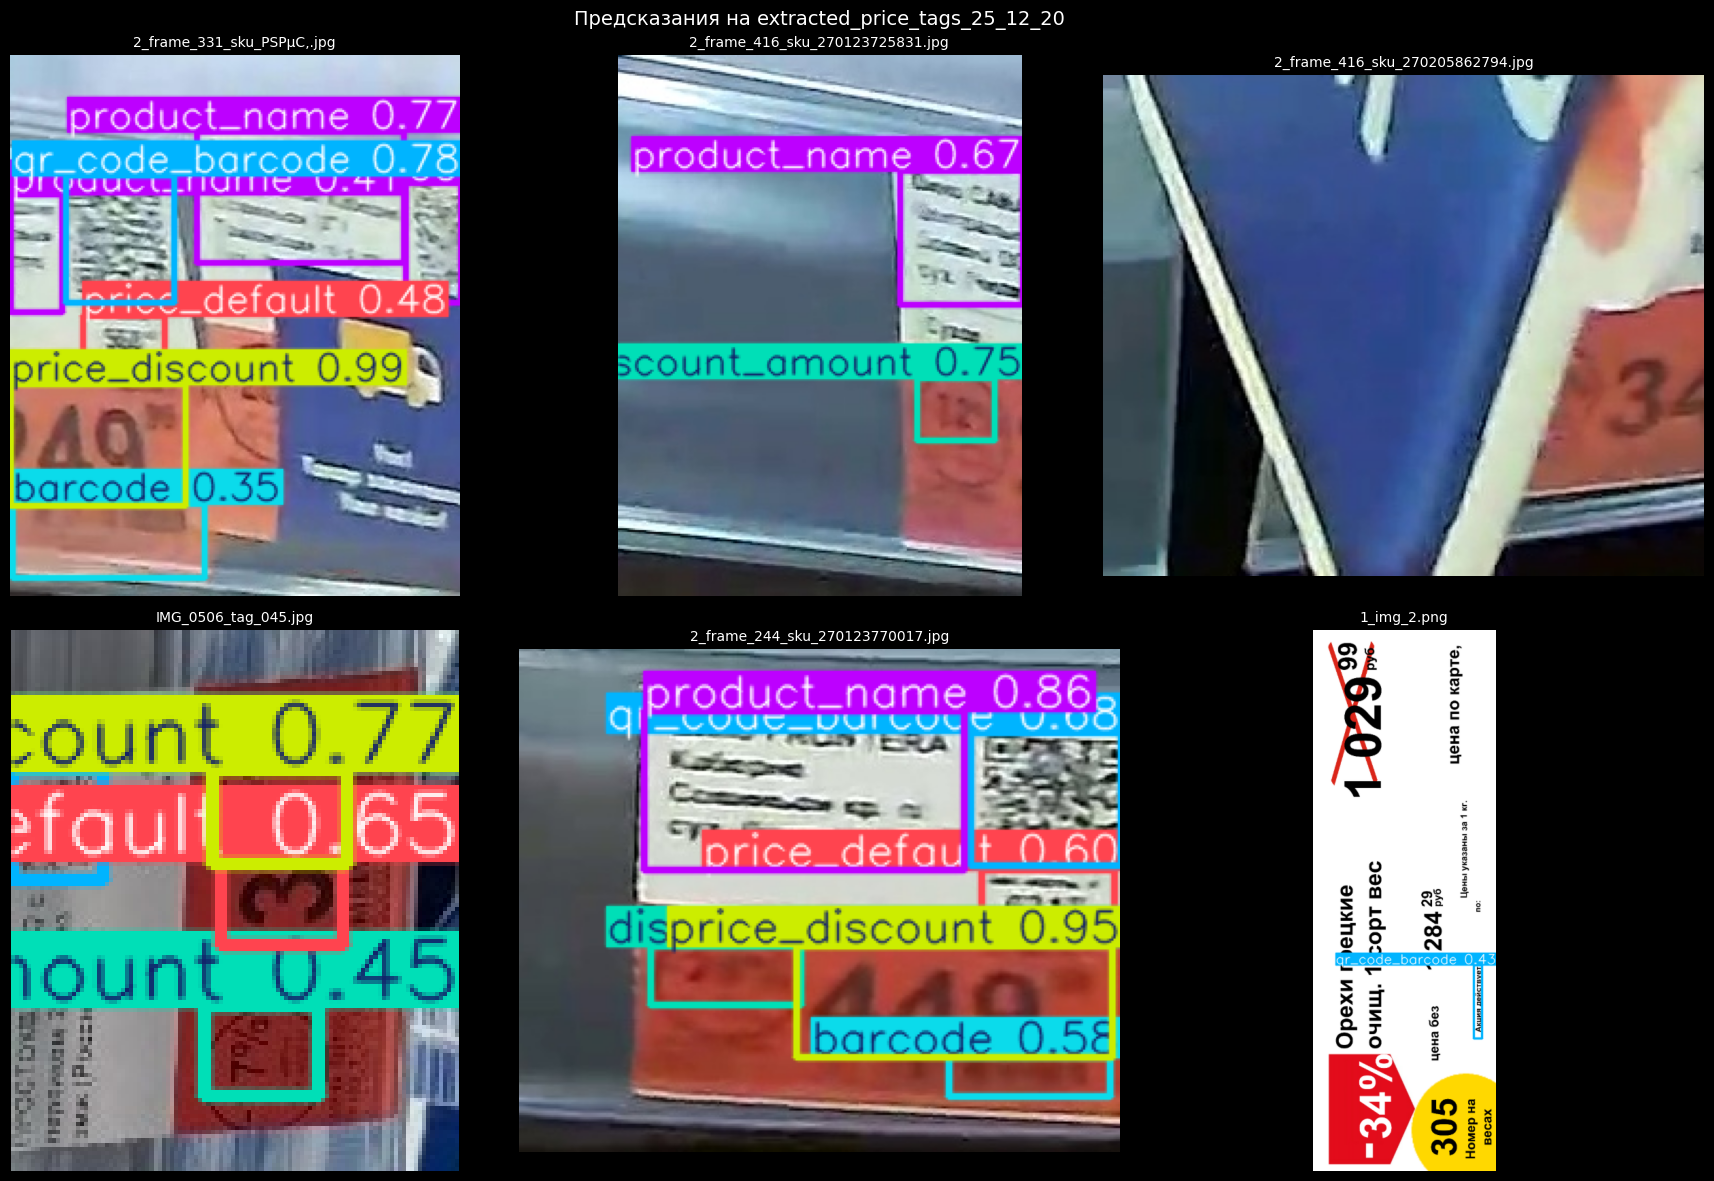

[INFO] Найдено 67 изображений в D:\Lenta-Tech-Life-Hack-2026\outputs\extracted_price_tags_25_12_20
D:\Lenta-Tech-Life-Hack-2026\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[INFO] ✓ Сохранено 10 примеров в D:\Lenta-Tech-Life-Hack-2026\runs\visualizations\extracted_price_tags_examples
[INFO] ✓ Результаты сохранены в: D:\Lenta-Tech-Life-Hack-2026\runs\visualizations\extracted_price_tags_25_12_20_ocr.csv
[INFO] ✓ Обработано изображений: 67
[INFO] Статистика распознавания:
[INFO]   - barcode: 1/67 изображений
[INFO]   - discount_amount: 6/67 изображений
[INFO]   - price_default: 4/67 изображений
[INFO]   - price_discount: 11/67 изображений
[INFO]   - product_name: 15/67 изображений


In [32]:
EXTRACTED_TAGS_DIR = PROJECT_ROOT / "outputs" / "extracted_price_tags_25_12_20"
EXTRACTED_VIS_DIR = PROJECT_ROOT / "runs" / "visualizations" / "extracted_price_tags_25_12_20"

def _decode_qr_with_padding(crop: np.ndarray, padding: int = 10) -> Optional[str]:
    """
    Декодирует QR-код из обрезанной области с добавлением паддинга.
    Возвращает строку или None, если QR не найден.
    """
    if crop is None or crop.size == 0:
        return None

    # Добавляем паддинг вокруг области QR-кода
    h, w = crop.shape[:2]
    padded = cv2.copyMakeBorder(
        crop,
        padding, padding, padding, padding,
        cv2.BORDER_CONSTANT,
        value=[255, 255, 255]  # белый фон
    )

    # Пробуем декодировать QR-код
    try:
        decoded_objects = decode(padded)
        if decoded_objects:
            # Возвращаем текст из первого найденного QR-кода
            return decoded_objects[0].data.decode('utf-8')
    except Exception as e:
        logger.debug(f"QR decode error: {e}")

    return None


def _enhance_for_ocr(img_array: np.ndarray) -> np.ndarray:
    """
    Улучшение изображения для OCR (применяется до распознавания).
    Включает: увеличение резкости, контраста, бинаризацию.
    """
    if img_array is None or img_array.size == 0:
        return img_array

    # Конвертируем в灰度, если цветное
    if len(img_array.shape) == 3:
        gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_array.copy()

    # 1. Увеличиваем контраст (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # 2. Бинаризация (адаптивная пороговая обработка)
    binary = cv2.adaptiveThreshold(
        enhanced, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # 3. Удаление шума
    denoised = cv2.medianBlur(binary, 3)

    # 4. Увеличение размера (если изображение маленькое)
    h, w = denoised.shape
    if h < 100 or w < 100:
        scale = max(2, int(200 / min(h, w)))
        denoised = cv2.resize(denoised, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)

    # Конвертируем обратно в 3-канальное для EasyOCR
    result = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)

    return result


def _ocr_from_image_array(img_array: np.ndarray, reader=None) -> Dict[str, object]:
    """
    Run EasyOCR on an image array and return joined text and average confidence.
    ПРИМЕНЯЕТ УЛУЧШЕНИЕ КАЧЕСТВА ДО РАСПОЗНАВАНИЯ.
    """
    if reader is None:
        reader = ocr_reader

    if img_array is None or img_array.size == 0:
        return {'raw_text': '', 'detections': 0, 'confidence_avg': 0.0}

    try:
        # Улучшаем изображение перед OCR
        enhanced_img = _enhance_for_ocr(img_array)

        results = reader.readtext(enhanced_img)
        texts = [r[1] for r in results if r[2] > 0.2]
        confs = [r[2] for r in results]

        return {
            'raw_text': ' '.join(texts),
            'detections': len(results),
            'confidence_avg': float(np.mean(confs)) if confs else 0.0
        }
    except Exception as e:
        logger.debug(f"OCR error: {e}")
        return {'raw_text': '', 'detections': 0, 'confidence_avg': 0.0}


# Ожидаемые классы
EXPECTED_CLASSES = [
    'additional_info',
    'barcode',
    'code',
    'discount_amount',
    'id_sku',
    'price_card',
    'price_default',
    'price_discount',
    'print_datetime',
    'product_name',
    'qr_code_barcode'
]


def _clean_price(text: str) -> str:
    """Очистка цены: оставляем только число с точкой."""
    if not text:
        return ''
    # Найти шаблон цены: числа с разделителем '.' или ',' и двумя знаками центов или без
    m = re.search(r"\d+[\d\s]*[.,]?\d{0,2}", text.replace('\xa0', ' '))
    if m:
        val = m.group(0)
        val = val.replace(' ', '').replace(',', '.')
        # Оставляем только первое найденное значение цены
        return val
    return ''


def _clean_date(text: str) -> str:
    """Очистка даты: оставляем первый найденный формат даты/времени."""
    if not text:
        return ''
    patterns = [r"\d{2}[./-]\d{2}[./-]\d{2,4}", r"\d{4}-\d{2}-\d{2}", r"\d{1,2}:\d{2}"]
    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(0)
    return ''


def _clean_code(text: str) -> str:
    """Очистка кода: возвращаем первую достаточно длинную буквенно-цифровую последовательность."""
    if not text:
        return ''
    m = re.search(r"[A-Za-z0-9\-]{4,}", text)
    return m.group(0) if m else ''


def _clean_generic(text: str) -> str:
    """Очистка общего текста: удаляем лишние пробелы."""
    if not text:
        return ''
    return ' '.join(str(text).split())


def _clean_qr_data(text: str) -> str:
    """
    Очистка данных из QR-кода.
    Если это ссылка или сложный JSON, возвращаем как есть.
    """
    if not text:
        return ''
    # Просто очищаем от лишних пробелов и спецсимволов
    cleaned = ' '.join(str(text).split())
    # Если это длинная строка без пробелов (например, JSON или ссылка), оставляем как есть
    if len(cleaned) > 50 and ' ' not in cleaned:
        return cleaned
    return cleaned


CLASS_CLEANERS = {
    'price_card': _clean_price,
    'price_default': _clean_price,
    'price_discount': _clean_price,
    'discount_amount': _clean_price,
    'print_datetime': _clean_date,
    'product_name': _clean_generic,
    'additional_info': _clean_generic,
    'barcode': _clean_code,
    'qr_code_barcode': _clean_qr_data,  # Специальный очиститель для QR
    'code': _clean_code,
    'id_sku': _clean_code,
}


def process_extracted_tags_with_model(
    model: YOLO,
    tags_folder: str,
    out_csv: str,
    rotate_ccw90: bool = True,
    conf: float = 0.25,
    imgsz: int = 640,
    reader=None,
    save_examples: int = 5,
    examples_dir: str = None,
):
    """
    Для каждого изображения находит объекты модели,
    применяет OCR или QR-декодирование и сохраняет результат в CSV.

    Важные изменения:
    - QR-коды обрабатываются ТОЛЬКО для класса qr_code_barcode
    - В одной ячейке ТОЛЬКО одно значение (без объединения через |)
    - Добавлен паддинг при декодировании QR
    - Улучшение качества перед OCR
    """
    if reader is None:
        reader = ocr_reader

    tags_path = pathlib.Path(tags_folder)
    if not tags_path.exists():
        logger.warning(f"Папка с тегами не найдена: {tags_path}")
        return None

    rows = []
    image_paths = sorted([p for p in tags_path.glob('*.jpg')])
    logger.info(f"Найдено {len(image_paths)} изображений в {tags_path}")

    # Подготавливаем папку для примеров
    examples_saved = []
    examples_path = None
    if examples_dir is not None and save_examples > 0:
        examples_path = pathlib.Path(examples_dir)
        examples_path.mkdir(parents=True, exist_ok=True)

    for idx, img_path in enumerate(image_paths):
        img = cv2.imread(str(img_path))
        if img is None:
            logger.debug(f"Не удалось загрузить изображение: {img_path}")
            continue

        original_img = img.copy()
        if rotate_ccw90:
            img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        # Инициализация строки с пустыми полями
        row = {c: '' for c in EXPECTED_CLASSES}
        row['filename'] = img_path.name

        results = model.predict(source=img, conf=conf, imgsz=imgsz, verbose=False)
        if not results:
            rows.append(row)
            continue

        res = results[0]
        boxes = getattr(res, 'boxes', None)
        if boxes is None or len(boxes) == 0:
            rows.append(row)
            continue

        # Получаем данные из boxes
        try:
            cls_arr = boxes.cls.cpu().numpy()
            xyxy = boxes.xyxy.cpu().numpy()
            confs = boxes.conf.cpu().numpy()
        except Exception:
            cls_arr = np.array(boxes.cls)
            xyxy = np.array(boxes.xyxy)
            confs = np.array(boxes.conf)

        img_annotated = img.copy()

        # Словарь для хранения уже установленных значений (избегаем дублирования)
        class_values = {}

        for cls_i, box, cconf in zip(cls_arr, xyxy, confs):
            cls_i = int(cls_i)

            # Получаем имя класса
            class_name = None
            try:
                if hasattr(model, 'model') and hasattr(model.model, 'names'):
                    class_name = model.model.names.get(cls_i, None)
                elif hasattr(model, 'names'):
                    class_name = model.names.get(cls_i, None)
            except Exception:
                class_name = None

            if class_name is None:
                class_name = EXPECTED_CLASSES[cls_i] if 0 <= cls_i < len(EXPECTED_CLASSES) else f'class_{cls_i}'

            x1, y1, x2, y2 = [int(max(0, v)) for v in box[:4]]
            crop = img[y1:y2, x1:x2]

            if crop is None or crop.size == 0:
                continue

            extracted_value = ""

            # Специальная обработка для QR-кодов
            if class_name == 'qr_code_barcode':
                # Пробуем декодировать QR-код с паддингом
                qr_result = _decode_qr_with_padding(crop, padding=15)
                if qr_result:
                    extracted_value = qr_result
                    logger.debug(f"QR декодирован: {qr_result[:50]}...")
                else:
                    # Если QR не найден, НЕ используем OCR для этой области
                    logger.debug(f"QR не найден в области {class_name} на {img_path.name}")
                    extracted_value = ""
            else:
                # Для остальных классов используем OCR с улучшением качества
                ocr_result = _ocr_from_image_array(crop, reader=reader)
                raw_text = ocr_result.get('raw_text', '')
                if raw_text:
                    cleaner = CLASS_CLEANERS.get(class_name, _clean_generic)
                    extracted_value = cleaner(raw_text)

            # Сохраняем значение в ячейку (только одно значение!)
            if extracted_value:
                # Если для этого класса уже есть значение - выбираем наиболее подходящее
                if class_name in class_values:
                    # Если новое значение длиннее или содержит больше цифр - возможно оно лучше
                    if len(extracted_value) > len(class_values[class_name]):
                        class_values[class_name] = extracted_value
                        logger.debug(f"Обновлено значение {class_name}: {extracted_value[:50]}")
                else:
                    class_values[class_name] = extracted_value

            # Рисуем прямоугольник для визуализации
            cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Добавляем текст с классом и значением (обрезаем длинные значения)
            display_text = class_name
            if extracted_value:
                short_val = extracted_value[:30] + "..." if len(extracted_value) > 30 else extracted_value
                display_text = f"{class_name}: {short_val}"

            cv2.putText(
                img_annotated, display_text,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4, (0, 255, 0), 1
            )

        # Переносим значения из class_values в row
        for class_name, value in class_values.items():
            row[class_name] = value

        rows.append(row)

        # Сохраняем примеры
        if examples_dir is not None and len(examples_saved) < save_examples:
            try:
                example_filename = f"example_{len(examples_saved):02d}_{img_path.name}"
                example_path = examples_path / example_filename
                cv2.imwrite(str(example_path), img_annotated)
                examples_saved.append(example_path)
                if len(examples_saved) == save_examples:
                    logger.info(f"✓ Сохранено {save_examples} примеров в {examples_path}")
            except Exception as e:
                logger.debug(f"Ошибка при сохранении примера: {e}")

    # Создаем DataFrame и сохраняем CSV
    df = pd.DataFrame(rows)
    out_csv_path = pathlib.Path(out_csv)
    out_csv_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv_path, index=False, encoding='utf-8-sig')

    logger.info(f"✓ Результаты сохранены в: {out_csv_path}")
    logger.info(f"✓ Обработано изображений: {len(rows)}")

    # Выводим статистику по найденным значениям
    non_empty_counts = {col: (df[col] != '').sum() for col in EXPECTED_CLASSES}
    logger.info("Статистика распознавания:")
    for class_name, count in non_empty_counts.items():
        if count > 0:
            logger.info(f"  - {class_name}: {count}/{len(rows)} изображений")

    return out_csv_path


# Использование
if trained_model is not None:
    # Визуализация
    _ = visualize_predictions_from_folder(
        trained_model,
        folder=str(EXTRACTED_TAGS_DIR),
        max_images=6,
        conf=0.25,
        imgsz=640,
        save_dir=str(VAL_VIS_DIR),
        title="Предсказания на extracted_price_tags_25_12_20",
        rotate_ccw90=True,
    )

    # Обработка всех извлечённых тегов
    OUT_OCR_CSV = PROJECT_ROOT / "runs" / "visualizations" / "extracted_price_tags_25_12_20_ocr.csv"
    EXAMPLES_DIR = PROJECT_ROOT / "runs" / "visualizations" / "extracted_price_tags_examples"

    process_extracted_tags_with_model(
        trained_model,
        tags_folder=str(EXTRACTED_TAGS_DIR),
        out_csv=str(OUT_OCR_CSV),
        rotate_ccw90=True,
        conf=0.25,
        imgsz=640,
        reader=ocr_reader,
        save_examples=10,
        examples_dir=str(EXAMPLES_DIR),
    )
else:
    logger.warning("Обработка пропущена: веса модели не найдены.")